# 4. Focalización de ondas en la ecuación de Helmholtz

## 4.1 El problema continuo

Queremos diseñar una permitividad $\varepsilon(\mathbf x)$ para que una onda plana incidente
se concentre en un punto. Partimos de la ecuación de Helmholtz en 2D

$$
\Delta u+k_0^2\,\varepsilon(\mathbf x)\,u=0,
\qquad k_0=\frac{\omega}{c_0},
$$ (eq:helmholtz)

con convención temporal $e^{-i\omega t}$ y una **onda plana incidente** en la dirección $+x$,
$u^{\rm inc}=e^{ik_0x}$. Los bordes se tratan con una **capa absorbente** que emula la
condición de radiación de Sommerfeld. Escribiendo el **campo total** como
$u=u^{\rm inc}+u^{s}$, el campo dispersado satisface

$$
\big(\Delta+k_0^2\,\varepsilon\big)\,u^{s}
=-k_0^2\,(\varepsilon-1)\,u^{\rm inc}.
$$ (eq:scattered)

El objetivo es la **intensidad en un punto** fijo $\mathbf x_f=(14,7)$:

$$
J(\varepsilon)=\big|u(\mathbf x_f)\big|^2 .
$$ (eq:focus-J)

## 4.2 Discretización

Sobre una malla de paso $h=\Delta x=\Delta y$ discretizamos el Laplaciano con el stencil de
cinco puntos e incorporamos la capa absorbente $\sigma(\mathbf x)\ge0$ como una parte
imaginaria. El problema directo discreto se escribe, en forma compacta, como

$$
A(\varepsilon)\,u=f,
\qquad
A=-\Delta_h-k_0^2\,\mathrm{diag}(\varepsilon)-i\,\mathrm{diag}(\sigma),
\qquad
f=k_0^2\,\mathrm{diag}(\varepsilon-1)\,u^{\rm inc},
$$ (eq:helmholtz-disc)

donde $u$ es el campo total discretizado y $f$ el término fuente del campo dispersado,
calculado evaluando {eq}`eq:scattered` en la malla. La matriz $A$ es **complejo simétrica**
($A^{T}=A$).

## 4.3 Aplicación del adjunto

Tratamos $\varepsilon$ como el vector de parámetros. El funcional discreto es
$J=|u_f|^2$, donde $u_f$ es la componente de $u$ en el nodo del foco. El Lagrangiano es

$$
\mathcal L(u,\varepsilon,\lambda)=\big|u_f\big|^2
+\big\langle\lambda,\,A(\varepsilon)u-f\big\rangle,
$$

con el producto interno euclídeo complejo. Para un funcional que depende de $u$ sólo a
través de $u_f$, el gradiente respecto de $u$ es $g_u=2u_f\,\mathbf e_f$ (una fuente en el
foco). La estacionariedad respecto de $u$ da la **ecuación adjunta discreta**

$$
\boxed{\;A^{H}\lambda=g_u\;,}
\qquad A^{H}=\overline{A}^{\,T},
$$ (eq:helmholtz-adj)

y el gradiente respecto de $\varepsilon$ (usando que $\delta A=-k_0^2\,\mathrm{diag}(\delta\varepsilon)$
y que $\varepsilon$ es real) resulta

$$
\boxed{\;
\nabla_\varepsilon J=k_0^2\,\mathrm{Re}\Big[\overline{\lambda}\odot u\Big].
\;}
$$ (eq:helmholtz-grad)

Aquí $\overline{\lambda}\odot u$ es el producto componente a componente. Como $A$ es complejo
simétrico, $A^{H}=\overline A$; en la práctica reutilizamos la factorización de $A$ para
resolver {eq}`eq:helmholtz-adj`.

## 4.4 Interpretación: la ecuación adjunta de Helmholtz

El operador $A^{H}$ es la discretización del **adjunto** (bajo el producto interno
hermitiano) del operador de Helmholtz, que es el mismo operador con la absorción
**conjugada**. La ecuación adjunta {eq}`eq:helmholtz-adj` es entonces la discretización de la
**ecuación de Helmholtz adjunta**

$$
\big(\Delta+k_0^2\,\varepsilon\big)\,\lambda=-g_u,
\qquad\text{con condición de radiación conjugada},
$$ (eq:helmholtz-adj-cont)

es decir, una ecuación de Helmholtz con una **fuente concentrada en el foco** y absorción de
signo opuesto. Físicamente, $\lambda$ es el campo **retropropagado** (fase-conjugado) desde
el foco. Por eso {eq}`eq:helmholtz-grad` dice que el gradiente es la **correlación cruzada**
del campo directo con el campo retropropagado: la imagen clásica de la migración.

## 4.5 Regularización

El problema de diseño es subdeterminado y no convexo. Para seleccionar soluciones lisas
agregamos un término de suavidad, es decir maximizamos

$$
J_{\rm reg}(\varepsilon)=J(\varepsilon)
-\frac{\mu}{2}\int_\Omega\big|\nabla\varepsilon\big|^2\,d\mathbf x .
$$

Con $P=\frac{\mu}{2}\|\nabla\varepsilon\|^2$ se tiene $\nabla_\varepsilon P=-\mu\Delta\varepsilon$,
de modo que la dirección de ascenso es $\nabla_\varepsilon J+\mu\,\Delta\varepsilon$. En la
implementación usamos un **suavizado gaussiano del gradiente** (ancho $s$) como
regularización implícita y acotamos $\varepsilon\in[0.25,4]$.

*(Comentario para FWI. El otro funcional típico es la discrepancia con datos,
$J=\frac12\sum_{s,r}|u_{s,r}-d_{s,r}|^2$. Allí $g_u$ es el **residuo** colocado en los
receptores, y {eq}`eq:helmholtz-grad` toma la forma
$\nabla_\varepsilon J=k_0^2\sum_s\mathrm{Re}[\overline{\lambda_s}\odot u_s]$, que es el
**kernel de migración**: la correlación cruzada del campo directo con el adjunto
retropropagado desde los receptores.)*

/home/martin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


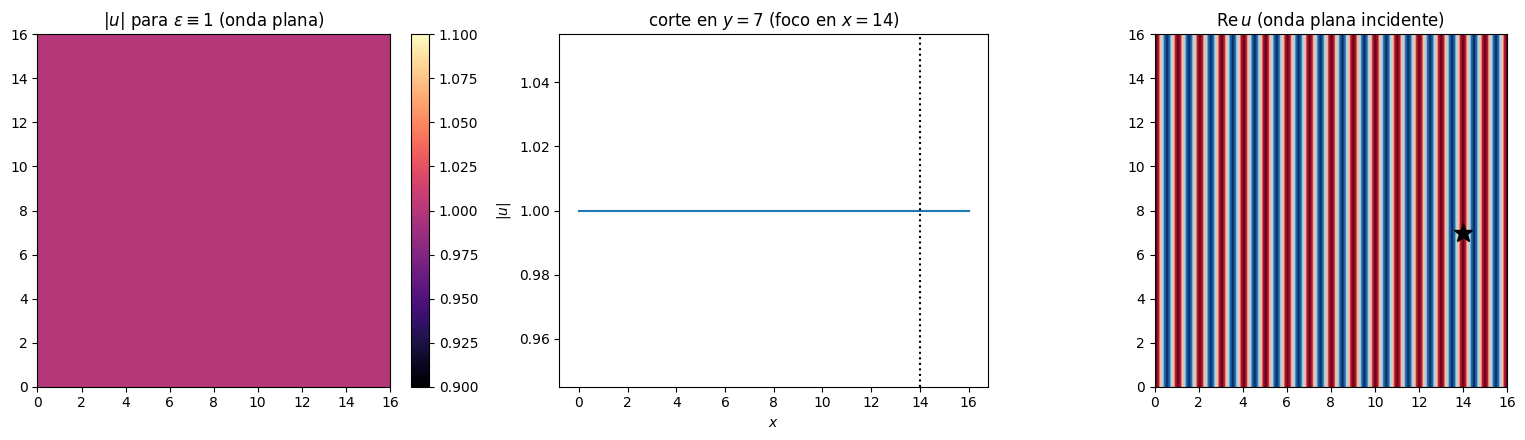

intensidad inicial en el foco J = 1.0000


In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# =========================================================
# Helmholtz 2D:  Lap(u) + k0^2 eps(x) u + i sigma u = 0
# incidencia: onda plana desde la izquierda, u_inc = exp(i k0 x)
# =========================================================
L = 16.0
N = 161
dx = L / (N - 1)
x = np.linspace(0, L, N)
X, Y = np.meshgrid(x, x, indexing="ij")
k0 = 2 * np.pi

# capa absorbente (sponge): amortiguamiento cuadratico en el borde
thk = 1.5
d_borde = np.minimum(np.minimum(X, L - X), np.minimum(Y, L - Y))
sigma = 8.0 * k0**2 * np.clip(1.0 - d_borde / thk, 0.0, 1.0) ** 2

# Laplaciano de 5 puntos
Dxx = sp.diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(N, N)) / dx**2
I = sp.identity(N, format="csc")
Lap = sp.kron(I, Dxx, format="csc") + sp.kron(Dxx, I, format="csc")


def make_A(eps):
    return (-(Lap + sp.diags(k0**2 * eps + 1j * sigma.ravel()))).tocsc()


# onda plana incidente
uinc = np.exp(1j * k0 * X)
uinc_flat = uinc.ravel()

# region de diseno: una lente (losa)
design = (X >= 5.0) & (X <= 8.0) & (Y >= 3.0) & (Y <= 11.0)
design_idx = np.where(design.ravel())[0]


def forward(eps, lu):
    # campo dispersado: (Lap + k0^2 eps) u_s = -k0^2 (eps-1) u_inc
    b = k0**2 * (eps - 1.0).ravel() * uinc_flat
    return lu.solve(b) + uinc_flat          # campo total


# foco en x_f = (14, 7)
x_f, y_f = 14.0, 7.0
fidx = int(round(x_f / dx)) * N + int(round(y_f / dx))


def focus_intensity(u):
    return np.abs(u[fidx]) ** 2


def focus_grad(u):
    g = np.zeros(N * N, dtype=complex)
    g[fidx] = 2.0 * u[fidx]
    return g


# ---- campo para eps = 1 (solo la onda plana) ----
u0 = forward(np.ones(N * N), spla.splu(make_A(np.ones(N * N)))).reshape(N, N)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
im0 = ax[0].imshow(np.abs(u0).T, origin="lower", extent=[0, L, 0, L], cmap="magma")
ax[0].set_title(r"$|u|$ para $\varepsilon\equiv 1$ (onda plana)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)
ax[1].plot(x, np.abs(u0[:, int(round(y_f / dx))]))
ax[1].axvline(x_f, color="k", ls=":"); ax[1].set_xlabel("$x$"); ax[1].set_ylabel(r"$|u|$")
ax[1].set_title("corte en $y=7$ (foco en $x=14$)")
ax[2].imshow(np.real(u0).T, origin="lower", extent=[0, L, 0, L], cmap="RdBu_r")
ax[2].plot(x_f, y_f, "k*", ms=14)
ax[2].set_title(r"$\mathrm{Re}\,u$ (onda plana incidente)")
plt.tight_layout(); plt.show()
print(f"intensidad inicial en el foco J = {focus_intensity(u0.ravel()):.4f}")

In [2]:
# ---- verificacion del gradiente adjunto contra diferencias finitas ----
eps = np.ones(N * N)
A = make_A(eps)
lu = spla.splu(A)
luH = spla.splu(A.conj().tocsc())
u = forward(eps, lu)

# (a) el gradiente g_u reproduce dJ para perturbaciones directas de u
gu = focus_grad(u)
rng = np.random.default_rng(0)
du = np.zeros(N * N, dtype=complex)
du[fidx] = rng.normal() + 1j * rng.normal()
t = 1e-7
dJ_num = (focus_intensity(u + t * du) - focus_intensity(u - t * du)) / (2 * t)
dJ_ana = np.real(np.vdot(gu, du))
print(f"dJ (perturbando u)  numerico = {dJ_num:+.4e}   adjunto = {dJ_ana:+.4e}")

# (b) el gradiente respecto de eps
lam = luH.solve(focus_grad(u))
grad = k0**2 * np.real(np.conj(lam) * u)

test = rng.choice(design_idx, size=6, replace=False)
delta = 1e-4
g_fd = []
for idx in test:
    ep = eps.copy(); ep[idx] += delta
    Jp = focus_intensity(forward(ep, spla.splu(make_A(ep))))
    em = eps.copy(); em[idx] -= delta
    Jm = focus_intensity(forward(em, spla.splu(make_A(em))))
    g_fd.append((Jp - Jm) / (2 * delta))
g_fd = np.array(g_fd)

print("Gradiente adjunto vs. diferencias finitas (nodos aleatorios de la lente)")
print("  adjunto  :", np.array2string(grad[test], precision=4, floatmode="fixed"))
print("  dif. fin.:", np.array2string(g_fd, precision=4, floatmode="fixed"))
print(f"  error relativo maximo: "
      f"{np.max(np.abs(grad[test] - g_fd) / np.abs(g_fd)):.3e}")

dJ (perturbando u)  numerico = +2.5146e-01   adjunto = +2.5146e-01


Gradiente adjunto vs. diferencias finitas (nodos aleatorios de la lente)
  adjunto  : [-0.0031 -0.0188 -0.0177 -0.0194 -0.0066 -0.0047]
  dif. fin.: [-0.0031 -0.0188 -0.0177 -0.0194 -0.0066 -0.0047]
  error relativo maximo: 2.115e-09


J inicial = 1.000  ->  J final = 17.317   (|u| en el foco = 4.161,  39 s)


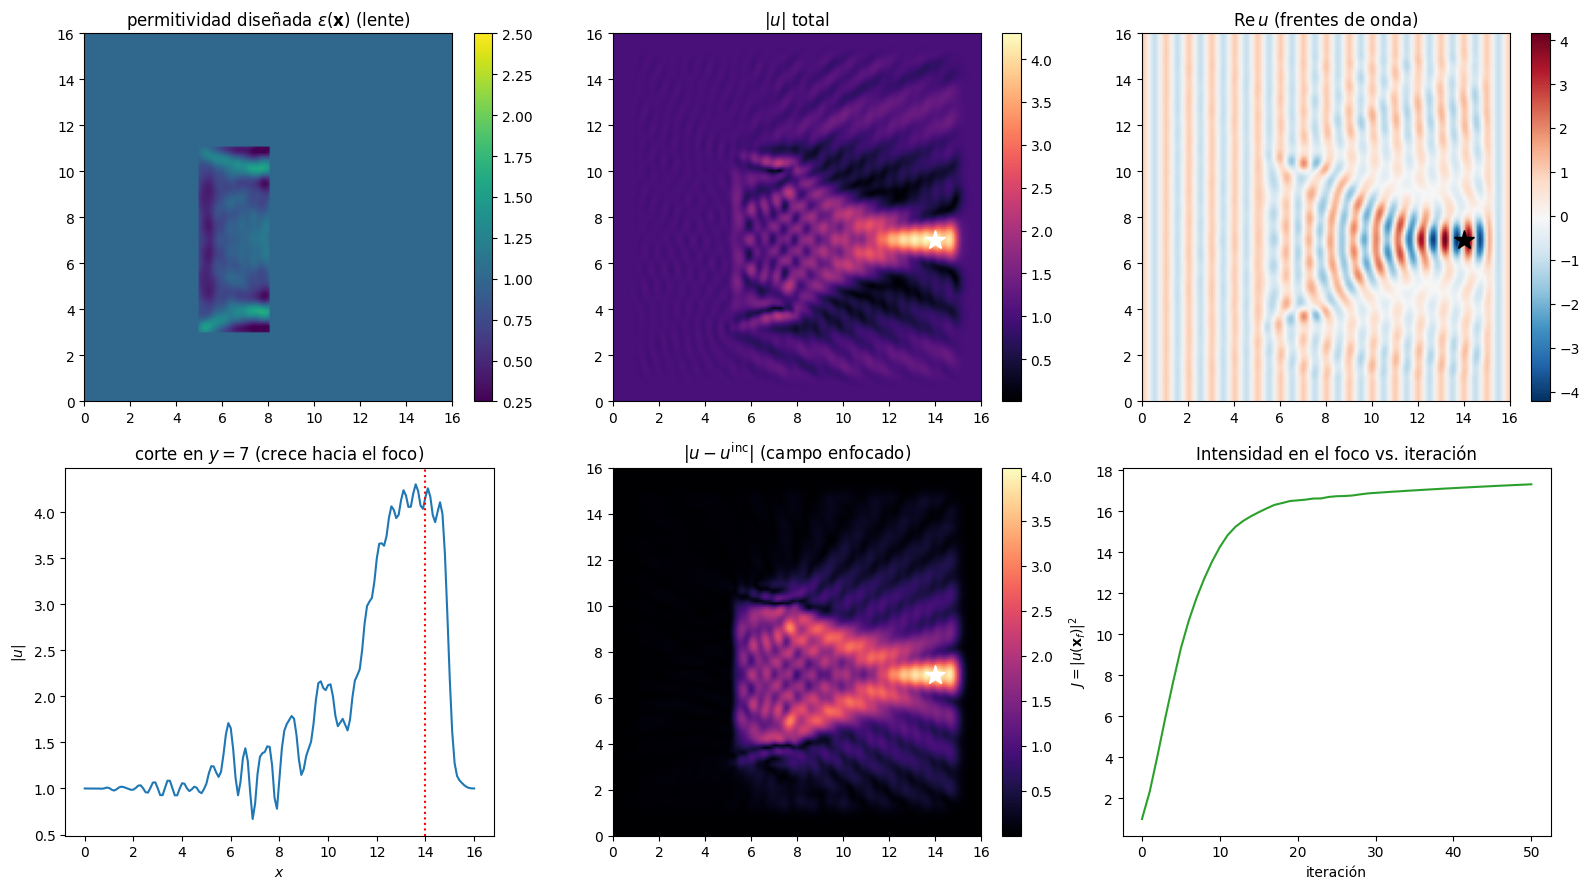

In [3]:
from scipy.ndimage import gaussian_filter
import time

# ---- ascenso por gradiente con regularizacion (lente focalizadora) ----
eps = np.ones((N, N))
J_hist = []
snaps_eps, snaps_u = [], []          # fotogramas para la animacion
t0 = time.time()

for it in range(50):
    A = make_A(eps.ravel())
    lu = spla.splu(A)
    luH = spla.splu(A.conj().tocsc())
    u = forward(eps.ravel(), lu)
    Jv = focus_intensity(u)
    J_hist.append(Jv)
    snaps_eps.append(eps.astype(np.float32).copy())
    snaps_u.append(np.abs(u.reshape(N, N)).astype(np.float32))

    # gradiente adjunto
    lam = luH.solve(focus_grad(u))
    g = k0**2 * np.real(np.conj(lam) * u).reshape(N, N)

    # regularizacion: suavizado gaussiano del gradiente
    g = gaussian_filter(np.where(design, g, 0.0), 2.0)
    gn = g / (np.abs(g).max() + 1e-30)

    # busqueda de linea (ascenso)
    step = 0.05
    for _ in range(3):
        et = np.clip(eps + step * gn, 0.25, 4.0)
        et[~design] = 1.0
        ut = forward(et.ravel(), spla.splu(make_A(et.ravel())))
        if focus_intensity(ut) > Jv:
            break
        step *= 0.5
    eps = np.clip(eps + step * gn, 0.25, 4.0)
    eps[~design] = 1.0

u = forward(eps.ravel(), spla.splu(make_A(eps.ravel())))
U = u.reshape(N, N)
J_final = focus_intensity(u)
J_hist.append(J_final)
snaps_eps.append(eps.astype(np.float32).copy())
snaps_u.append(np.abs(U).astype(np.float32))

print(f"J inicial = {J_hist[0]:.3f}  ->  J final = {J_final:.3f}"
      f"   (|u| en el foco = {np.sqrt(J_final):.3f},  {time.time() - t0:.0f} s)")

fig, ax = plt.subplots(2, 3, figsize=(16, 9))
im = ax[0, 0].imshow(eps.T, origin="lower", vmin=0.25, vmax=2.5,
                     extent=[0, L, 0, L], cmap="viridis")
ax[0, 0].set_title(r"permitividad diseñada $\varepsilon(\mathbf{x})$ (lente)")
plt.colorbar(im, ax=ax[0, 0], fraction=0.046)

im = ax[0, 1].imshow(np.abs(U).T, origin="lower", extent=[0, L, 0, L], cmap="magma")
ax[0, 1].set_title(r"$|u|$ total"); ax[0, 1].plot(x_f, y_f, "w*", ms=15)
plt.colorbar(im, ax=ax[0, 1], fraction=0.046)

im = ax[0, 2].imshow(np.real(U).T, origin="lower", extent=[0, L, 0, L], cmap="RdBu_r")
ax[0, 2].set_title(r"$\mathrm{Re}\,u$ (frentes de onda)")
ax[0, 2].plot(x_f, y_f, "k*", ms=15)
plt.colorbar(im, ax=ax[0, 2], fraction=0.046)

ax[1, 0].plot(x, np.abs(U[:, int(round(y_f / dx))]))
ax[1, 0].axvline(x_f, color="r", ls=":"); ax[1, 0].set_xlabel("$x$")
ax[1, 0].set_ylabel(r"$|u|$"); ax[1, 0].set_title("corte en $y=7$ (crece hacia el foco)")

im = ax[1, 1].imshow(np.abs(U - u0).T, origin="lower", extent=[0, L, 0, L], cmap="magma")
ax[1, 1].set_title(r"$|u-u^{\rm inc}|$ (campo enfocado)"); ax[1, 1].plot(x_f, y_f, "w*", ms=15)
plt.colorbar(im, ax=ax[1, 1], fraction=0.046)

ax[1, 2].plot(J_hist, "C2")
ax[1, 2].set_xlabel("iteración"); ax[1, 2].set_ylabel(r"$J=|u(\mathbf{x}_f)|^2$")
ax[1, 2].set_title("Intensidad en el foco vs. iteración")
plt.tight_layout(); plt.show()

## 4.6 Película del descenso por gradiente

Animamos las iteraciones: a la izquierda la **permitividad** $\varepsilon(\mathbf x)$ que va
cambiando, al centro el **campo generado** $|u|$ (con el foco marcado con una estrella) y a la
derecha la **intensidad en el foco** $J$ con el iterado actual marcado. Se ve cómo se forma
la lente y cómo el campo se va concentrando en $\mathbf x_f=(14,7)$.

<video controls src="focalizacion_iter.mp4" width="720" loop muted></video>

In [4]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video
import matplotlib.pyplot as plt

# ---- pelicula de las iteraciones ----
figA, axA = plt.subplots(1, 3, figsize=(12.5, 3.4))
vmaxU = max(s.max() for s in snaps_u)


def frame(i):
    for a in axA:
        a.clear()
    axA[0].imshow(snaps_eps[i].T, origin="lower", extent=[0, L, 0, L],
                  cmap="viridis", vmin=0.25, vmax=2.5)
    axA[0].set_title(r"$\varepsilon(\mathbf{x})$,  iteración %d" % i)
    axA[1].imshow(snaps_u[i].T, origin="lower", extent=[0, L, 0, L],
                  cmap="magma", vmin=0, vmax=vmaxU)
    axA[1].plot(x_f, y_f, "w*", ms=12)
    axA[1].set_title(r"$|u|$  (campo)")
    axA[2].plot(J_hist, "C2")
    axA[2].plot(i, J_hist[i], "ro")
    axA[2].set_xlabel("iteración"); axA[2].set_ylabel(r"$J=|u(\mathbf{x}_f)|^2$")
    axA[2].set_title("intensidad en el foco")
    axA[2].set_xlim(0, len(J_hist) - 1); axA[2].set_ylim(0, max(J_hist) * 1.05)
    plt.tight_layout()


anim = FuncAnimation(figA, frame, frames=len(snaps_eps), interval=200)
anim.save("focalizacion_iter.mp4", writer=FFMpegWriter(fps=6), dpi=80)
plt.close(figA)
print("pelicula guardada en focalizacion_iter.mp4")
Video("focalizacion_iter.mp4", embed=True)

pelicula guardada en focalizacion_iter.mp4
